In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os

if 'google.colab' in sys.modules:
    REPO_NAME = "study-deep-learning"
    REPO_URL = f"https://github.com/miyayudai/{REPO_NAME}.git"
    TARGET_DIR = f"/content/{REPO_NAME}"
    CH_DIR = f"{TARGET_DIR}/12"

    # 1. リポジトリのダウンロード (未ダウンロード時のみ)
    if not os.path.exists(TARGET_DIR):
        print("📦 リポジトリをダウンロード中...")
        res = os.system(f"git clone {REPO_URL} {TARGET_DIR} 2>&1")
        
        # Private リポジトリ等で認証が必要な場合の自動救済
        if res != 0 or not os.path.exists(TARGET_DIR):
            token = None
            try:
                from google.colab import userdata
                token = userdata.get('GITHUB_TOKEN')
            except Exception:
                pass
            
            if not token:
                import getpass
                print("🔒 リポジトリが非公開(Private)の場合、GitHub Personal Access Token (PAT) が必要です。")
                print("※公開(Public)リポジトリの場合はそのまま Enter を押してください。")
                token = getpass.getpass("GitHub Token (空欄可): ").strip()
            
            if token:
                auth_url = f"https://{token}@github.com/miyayudai/{REPO_NAME}.git"
                os.system(f"git clone {auth_url} {TARGET_DIR}")

    # 2. 依存パッケージとローカルモジュールのインストール
    print("⚙️ 環境セットアップ中...")
    if os.path.exists(TARGET_DIR):
        if TARGET_DIR not in sys.path:
            sys.path.insert(0, TARGET_DIR)
        req_path = os.path.join(TARGET_DIR, "requirements.txt")
        if os.path.exists(req_path):
            get_ipython().system(f"pip install -q -r {req_path}")
            get_ipython().system(f"pip install -q -e {TARGET_DIR}")
        if os.path.exists(CH_DIR):
            get_ipython().run_line_magic("cd", CH_DIR)
        else:
            get_ipython().run_line_magic("cd", TARGET_DIR)
        print("✅ 準備完了！このまま下のセルを実行できます。")
    else:
        print("⚠️ リポジトリのクローンがスキップされたため、必須パッケージを個別インストールします...")
        get_ipython().system("pip install -q pandas scikit-learn seaborn pillow")
        print("✅ パッケージインストール完了。")

# 第12章 トランスフォーマー (Transformers)
## 12.4 マルチモーダル・トランスフォーマー (Multimodal Transformers)

本ノートブックは、Christopher M. Bishop & Hugh Bishop (2024)『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』第12章「トランスフォーマー」第12.4節「マルチモーダル・トランスフォーマー (Multimodal Transformers)」の全5小節（12.4.1 〜 12.4.5）の完全な理論解説、数学的定式化（式 12.37 〜 式 12.38）、教科書図版（Figure 12.22 〜 12.27 全6枚）の完全再現、共通モジュール実装、および数値検証を提供します。

---

### 目次
1. **環境設定と共通モジュールのインポート**
2. **12.4.1 ビジョン・トランスフォーマー (Vision Transformers, Figure 12.22)**
   - 画像のパッチ分割 ($P \times P$)、平坦化 (Flatten)、線形射影 $E$
   - 学習可能なクラス分類トークン $\langle \text{class} \rangle$ と1次元学習可能位置埋め込み $E_{\text{pos}}$
   - トランスフォーマー・エンコーダと線形ソフトマックス (LSM) 分類ヘッド
   - 帰納バイアス (Inductive Bias) と訓練データ規模のトレードオフ（CNN との比較）
3. **12.4.2 生成画像トランスフォーマー (Generative Image Transformers, Figure 12.23, 12.24, 式 12.37 〜 12.38)**
   - 画像の自己回帰分解とラスタースキャン順序 (Raster Scan, 図 12.23, 式 12.37)
   - 自己回帰画像サンプリング過程 (Figure 12.24)
   - 連続分布 vs 離散分布（平均化によるぼやけ問題 vs 多峰性表現力）
   - ベクトル量子化 (Vector Quantization / VQ, 式 12.38) とコードブック最近傍探索
   - ストレート・スルー勾配推定法 (Straight-Through Estimator, STE)
4. **12.4.3 音声データと音声トランスフォーマー (Audio Data, Figure 12.25)**
   - 音声波形からメル・スペクトログラム (Mel Spectrogram) への変換
   - 周波数メル尺度変換 ($m = 2595 \log_{10}(1 + f/700)$) と三角フィルタバンク
   - ザトウクジラの歌のメル・スペクトログラム再現 (Figure 12.25)
   - 音声スペクトログラム・トランスフォーマー (AST) のパッチ分割とトークン化
5. **12.4.4 テキスト音声合成 (Text-to-Speech / Vall-E, Figure 12.26)**
   - 従来の回帰アプローチの限界（多峰性の平均化と話者適応の困難）
   - 条件付き言語モデルとしての音声生成
   - Vall-E アーキテクチャ (Figure 12.26)：テキストプロンプト＋音響プロンプトによるゼロショット話者模倣
6. **12.4.5 視覚と言語の統合トランスフォーマー (Vision and Language Transformers, Figure 12.27)**
   - 統一語彙体系によるマルチモーダル表現 ($V = V_{\text{text}} \cup V_{\text{image}}$)
   - 系列変換モデル (Parti) と統一自己回帰モデル (CM3 / CM3Leon)
   - CM3Leon のマルチモーダルタスク (Figure 12.27)：Text-to-Image, Image-to-Text, Inpainting, Editing
7. **数値シミュレーション・アルゴリズム検証**
8. **まとめと章末演習問題 (Exercises 12.1 〜 12.16) への展開**


In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# リポジトリルートをパスに追加
repo_root = Path.cwd().parent if Path.cwd().name == "12" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.plot_utils import setup_style
from common.multimodal_transformers import (
    VisionTransformer,
    VectorQuantizer,
    AutoregressiveImageGenerator,
    AudioMelSpectrogramProcessor,
    MultimodalTokenManager,
    generate_figure_12_22,
    generate_figure_12_23,
    generate_figure_12_24,
    generate_figure_12_25,
    generate_figure_12_26,
    generate_figure_12_27,
)

setup_style()
print("Setup complete. Multimodal Transformer modules and figure generators ready.")


Setup complete. Multimodal Transformer modules and figure generators ready.


## 2. ビジョン・トランスフォーマー (Vision Transformers, Section 12.4.1)

トランスフォーマーは当初、系列言語データの処理のために開発されましたが、入力データに対する事前の構造的仮定（CNN の局所性や並進等変性など）をほとんど持たない汎用アーキテクチャであるため、コンピュータビジョンや音声など多様なモダリティへと急速に拡大しました。

### 2.1 パッチ分割とトークン化 (Patch Partitioning & Tokenization)
画像 $\mathbf{x} \in \mathbb{R}^{H \times W \times C}$ を画素単位でトークン化すると、トークン数 $HW$ の2乗でメモリ消費量と計算量が爆発します。そこで、画像を大きさ $P \times P$（典型的には $P=16$）の互いに重なり合わない $N = \frac{HW}{P^2}$ 個のパッチへと分割し、各パッチを平坦化して1次元ベクトル $\mathbf{x}_p \in \mathbb{R}^{N \times (P^2 C)}$ とします。

1. **線形射影 (Linear Projection)**: 各パッチを行列 $E \in \mathbb{R}^{(P^2 C) \times D}$ で潜在次元 $D$ へと写像します。
2. **クラス分類トークン ($\langle \text{class} \rangle$ Token)**: 先頭に学習可能なトークン $\mathbf{x}_{\text{class}} \in \mathbb{R}^{1 \times D}$ を付加します。
3. **1次元位置埋め込み (1D Positional Embeddings)**: トークン位置情報を保持するため、学習可能な1次元位置埋め込み $E_{\text{pos}} \in \mathbb{R}^{(N+1) \times D}$ を加算します：
   $$\mathbf{z}_0 = [\mathbf{x}_{\text{class}}; \, \mathbf{x}_p^1 E; \, \dots; \, \mathbf{x}_p^N E] + E_{\text{pos}}$$
4. **トランスフォーマー・エンコーダ**: $L$ 層の標準的なエンコーダ層（Pre-LN Multi-Head Attention + MLP）を通過させます。
5. **線形ソフトマックス分類器 (LSM)**: 最終層の $\langle \text{class} \rangle$ トークンに対応する出力 $\mathbf{z}_L^0$ を取り出し、LayerNorm と線形変換＋Softmax（式 12.5）を適用してクラス確率ベクトル $\mathbf{c}$ を出力します。

### 2.2 帰納バイアスと訓練規模のトレードオフ
CNN は画像の局所性と並進等変性という強力な「帰納バイアス (Inductive Bias)」を持ちますが、ViT の空間的帰納バイアスはパッチ分割のみに留まります。このため ViT は空間幾何構造をデータから直接学習する必要があり、小規模データセットでは過学習しやすい一方、超大規模データセットで事前学習すると CNN の性能限界を超え、より高い精度に収束します（Sutton の「苦い教訓 (The Bitter Lesson)」の実証例）。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/12/result/fig_12_22_vit_architecture.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_12_22_vit_architecture.png


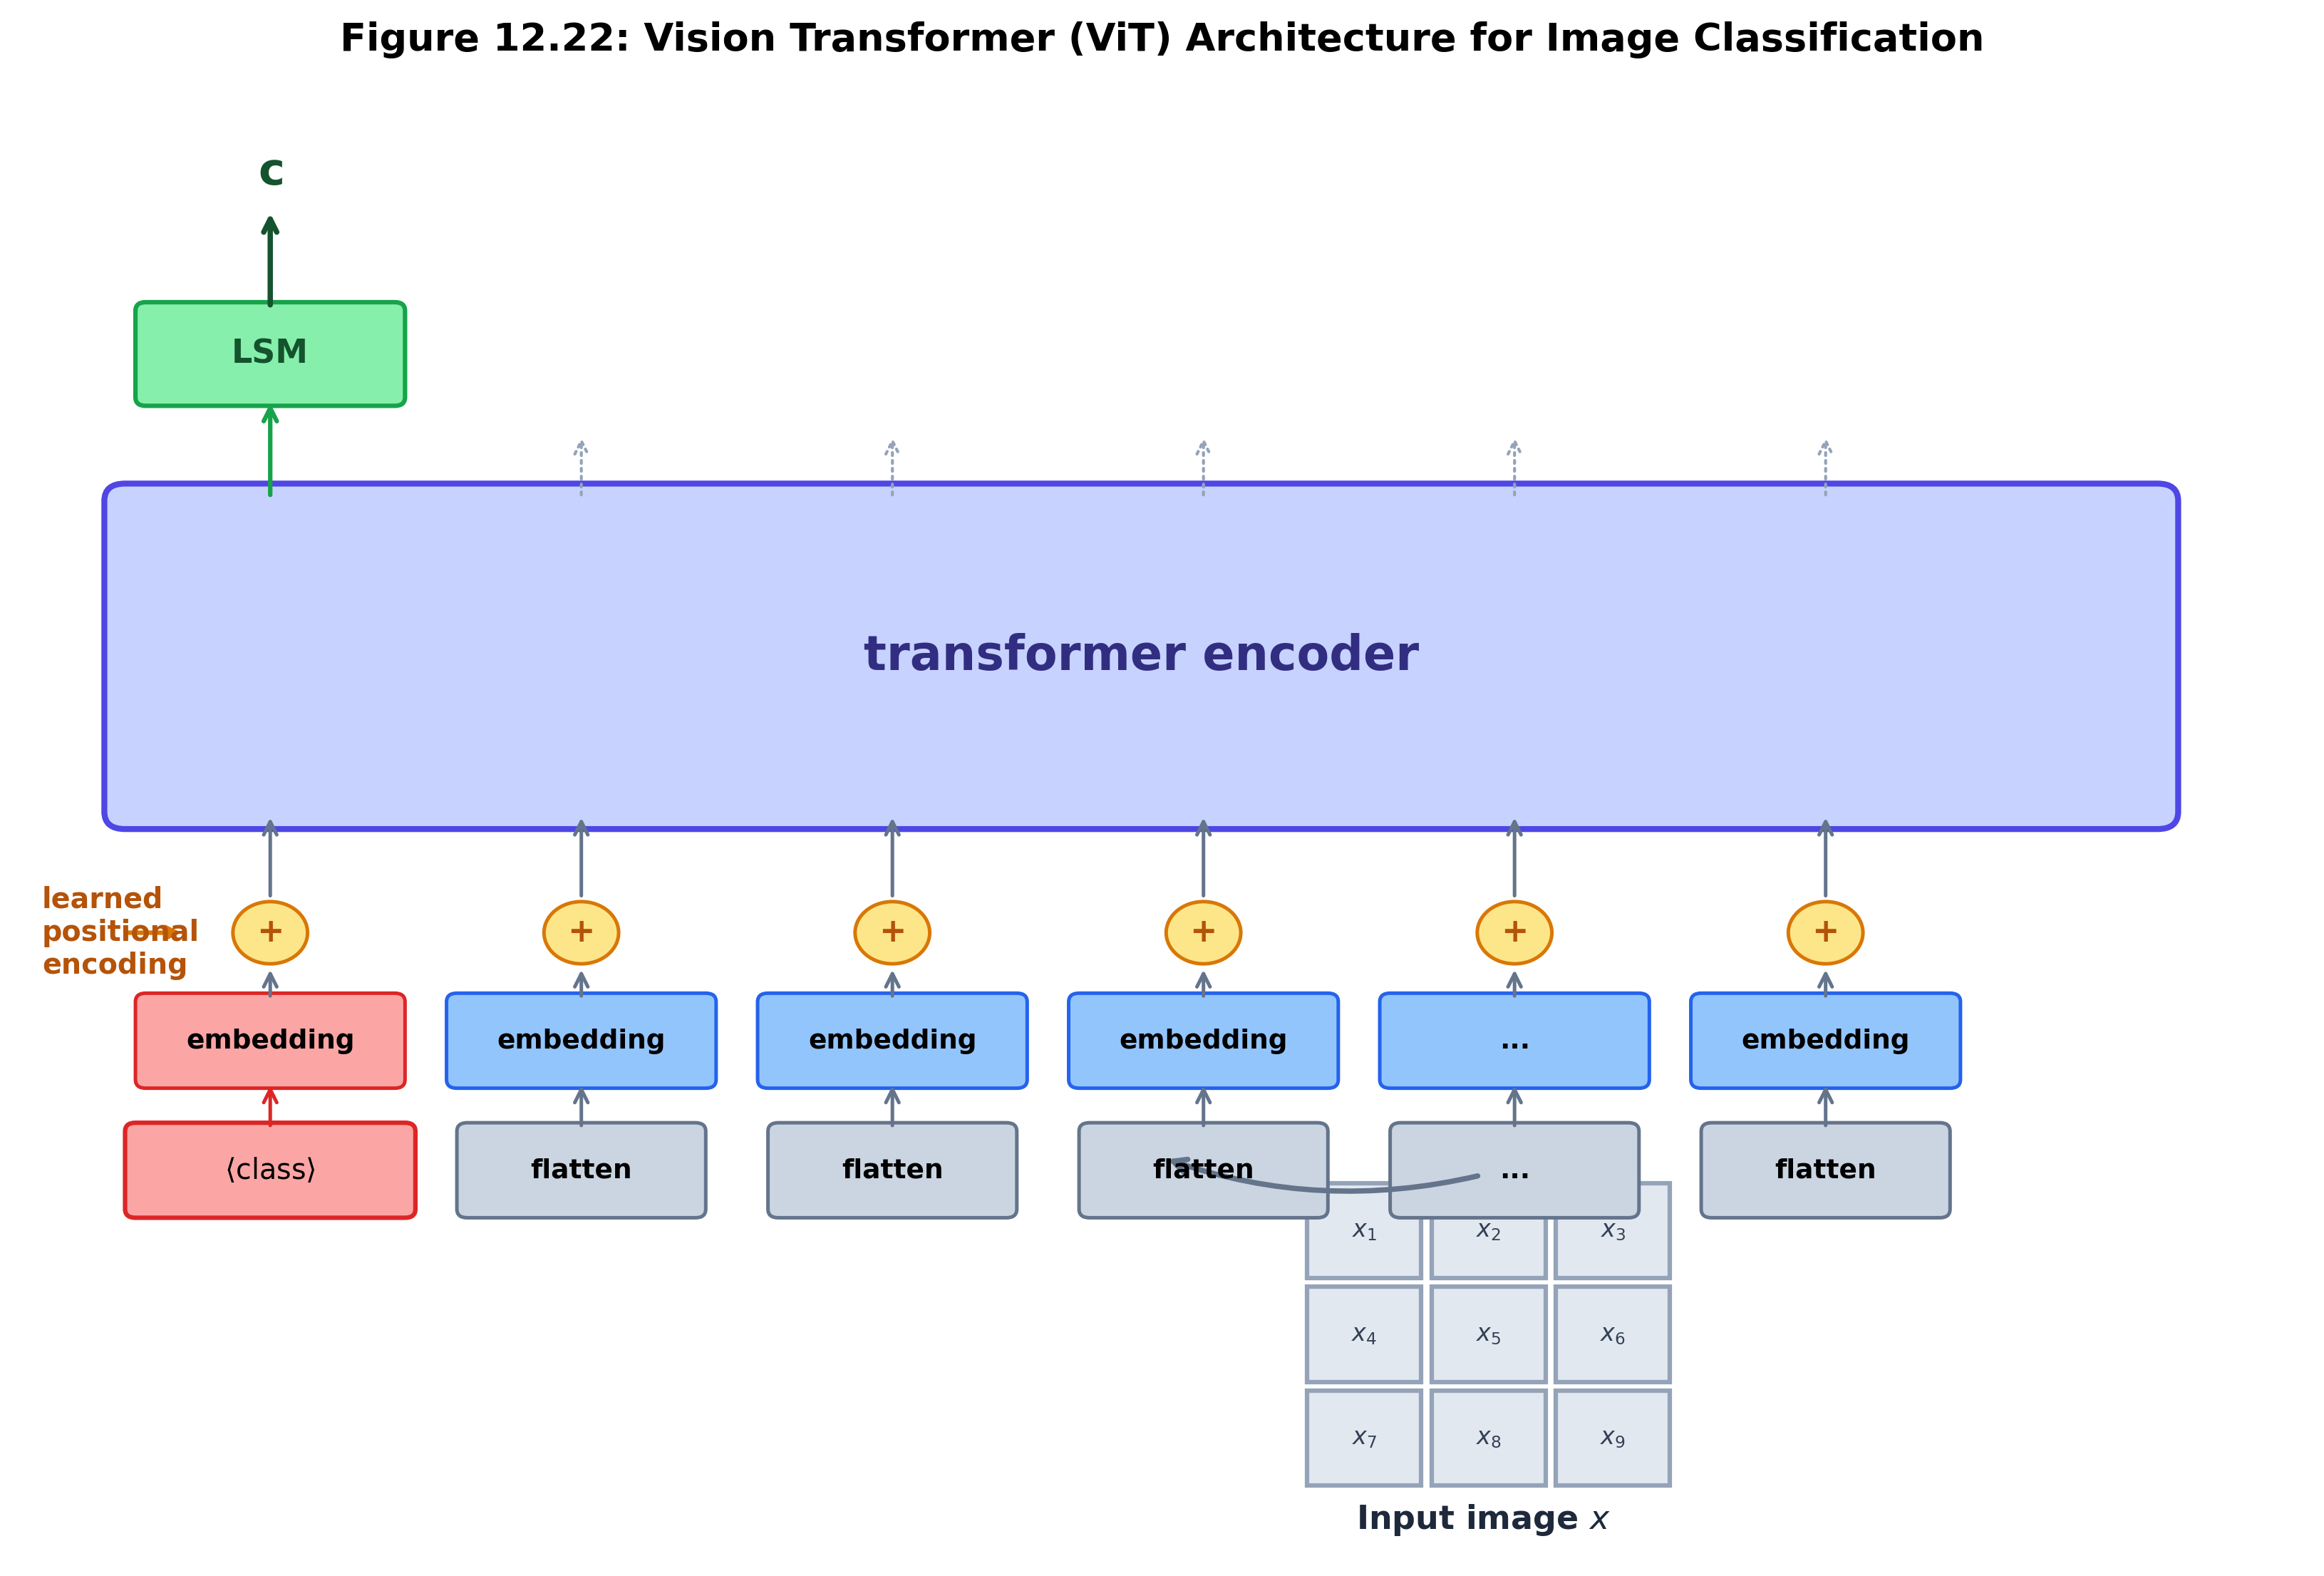

入力画像テンソル形状: (2, 32, 32, 3)
パッチ数 N: 16, パッチ次元: 192
出力ロジット形状: (2, 10), 確率形状: (2, 10)
各バッチの予測確率和: [1. 1.] (厳密に 1.0 に規格化)
抽出されたエンコーダ層数: 3, 各層注意マップ形状: (2, 4, 17, 17)


In [2]:
# Figure 12.22 ViT アーキテクチャ図の生成と表示
fig_12_22 = generate_figure_12_22()
plt.show()

# VisionTransformer クラスの動作検証
H, W, C = 32, 32, 3
P = 8
vit = VisionTransformer(
    img_size=(H, W),
    patch_size=P,
    in_channels=C,
    num_classes=10,
    d_model=64,
    num_heads=4,
    num_layers=3,
    mlp_dim=128,
    seed=42,
)

# ダミー画像データの作成とフォワードパス
rng = np.random.default_rng(42)
dummy_img = rng.uniform(0, 1, size=(2, H, W, C))
logits, probs, attn_maps = vit.forward(dummy_img, return_attention_maps=True)

print(f"入力画像テンソル形状: {dummy_img.shape}")
print(f"パッチ数 N: {vit.num_patches}, パッチ次元: {vit.patch_dim}")
print(f"出力ロジット形状: {logits.shape}, 確率形状: {probs.shape}")
print(f"各バッチの予測確率和: {np.sum(probs, axis=-1)} (厳密に 1.0 に規格化)")
print(f"抽出されたエンコーダ層数: {len(attn_maps)}, 各層注意マップ形状: {attn_maps[0].shape}")


## 3. 生成画像トランスフォーマー (Generative Image Transformers, Section 12.4.2)

言語モデルで培われた自己回帰トランスフォーマーを画像生成へ適用するには、本質的に2次元の空間構造を持つ画像に対して「順序」を定義する必要があります。

### 3.1 ラスタースキャン順序と自己回帰分解 (式 12.37)
任意の確率変数列 $\mathbf{x}_1, \dots, \mathbf{x}_N$ の同時分布は、確率の乗法定理により厳密に因数分解できます：
$$p(\mathbf{x}_1, \dots, \mathbf{x}_N) = \prod_{n=1}^N p(\mathbf{x}_n \mid \mathbf{x}_1, \dots, \mathbf{x}_{n-1}) \tag{12.37}$$

2次元画像において最も標準的な順序付けが **ラスタースキャン順序 (Raster Scan)** です（図 12.23）。左上 $(1, 1)$ から行ごとに右方向へ進み、行末に達すると次の行の左端へ戻る順序付けにより、2次元グリッドが1次元系列 $x_1, \dots, x_N$ へと一意に直列化されます。

### 3.2 連続分布 vs 離散分布の表現力
- **連続分布（ガウス分布＋平均二乗誤差回帰）**: 最尤推定で学習すると、多峰性を持つターゲットに対して「平均値」を予測する傾向があり、ぼやけた (blurry) 画像が生成されてしまいます（第6章 混合密度ネットワークで見た現象と同様）。
- **離散カテゴリカル分布＋ソフトマックス**: 離散分布は多峰性を容易に表現できます（例えば、画素が「黒」または「白」のどちらかであり、中間の「灰色」ではない状態を的確に学習可能）。

### 3.3 ベクトル量子化 (Vector Quantization / VQ, 式 12.38)
RGB 画素を直接 8-bit（$2^{24} \approx 1600$ 万値）で離散化するとソフトマックス空間が過大となり、またパッチ単位（$16 \times 16$ の2値パッチでも $2^{256} \approx 10^{77}$ 通り）では次元の爆発が起きます。
これを解決するのが **ベクトル量子化 (Vector Quantization)** です：

$D$ 次元のデータベクトル $\mathbf{x}_n$ に対し、$K$ 個のコードブックベクトル $\mathcal{C} = \{\mathbf{c}_1, \dots, \mathbf{c}_K\}$ を導入し、ユークリッド距離の最近傍コードブックベクトルへ近似写像します：
$$\mathbf{x}_n \to \arg\min_{\mathbf{c}_k \in \mathcal{C}} \|\mathbf{x}_n - \mathbf{c}_k\|_2^2 \tag{12.38}$$

- **ストレート・スルー勾配推定法 (Straight-Through Estimator, STE)**: 最近傍選択 ($\arg\min$) は非可微分ですが、誤差逆伝播時に勾配をそのままバイパスして通過させることで、端から端までの勾配学習を可能にします。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/12/result/fig_12_23_raster_scan.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_12_23_raster_scan.png


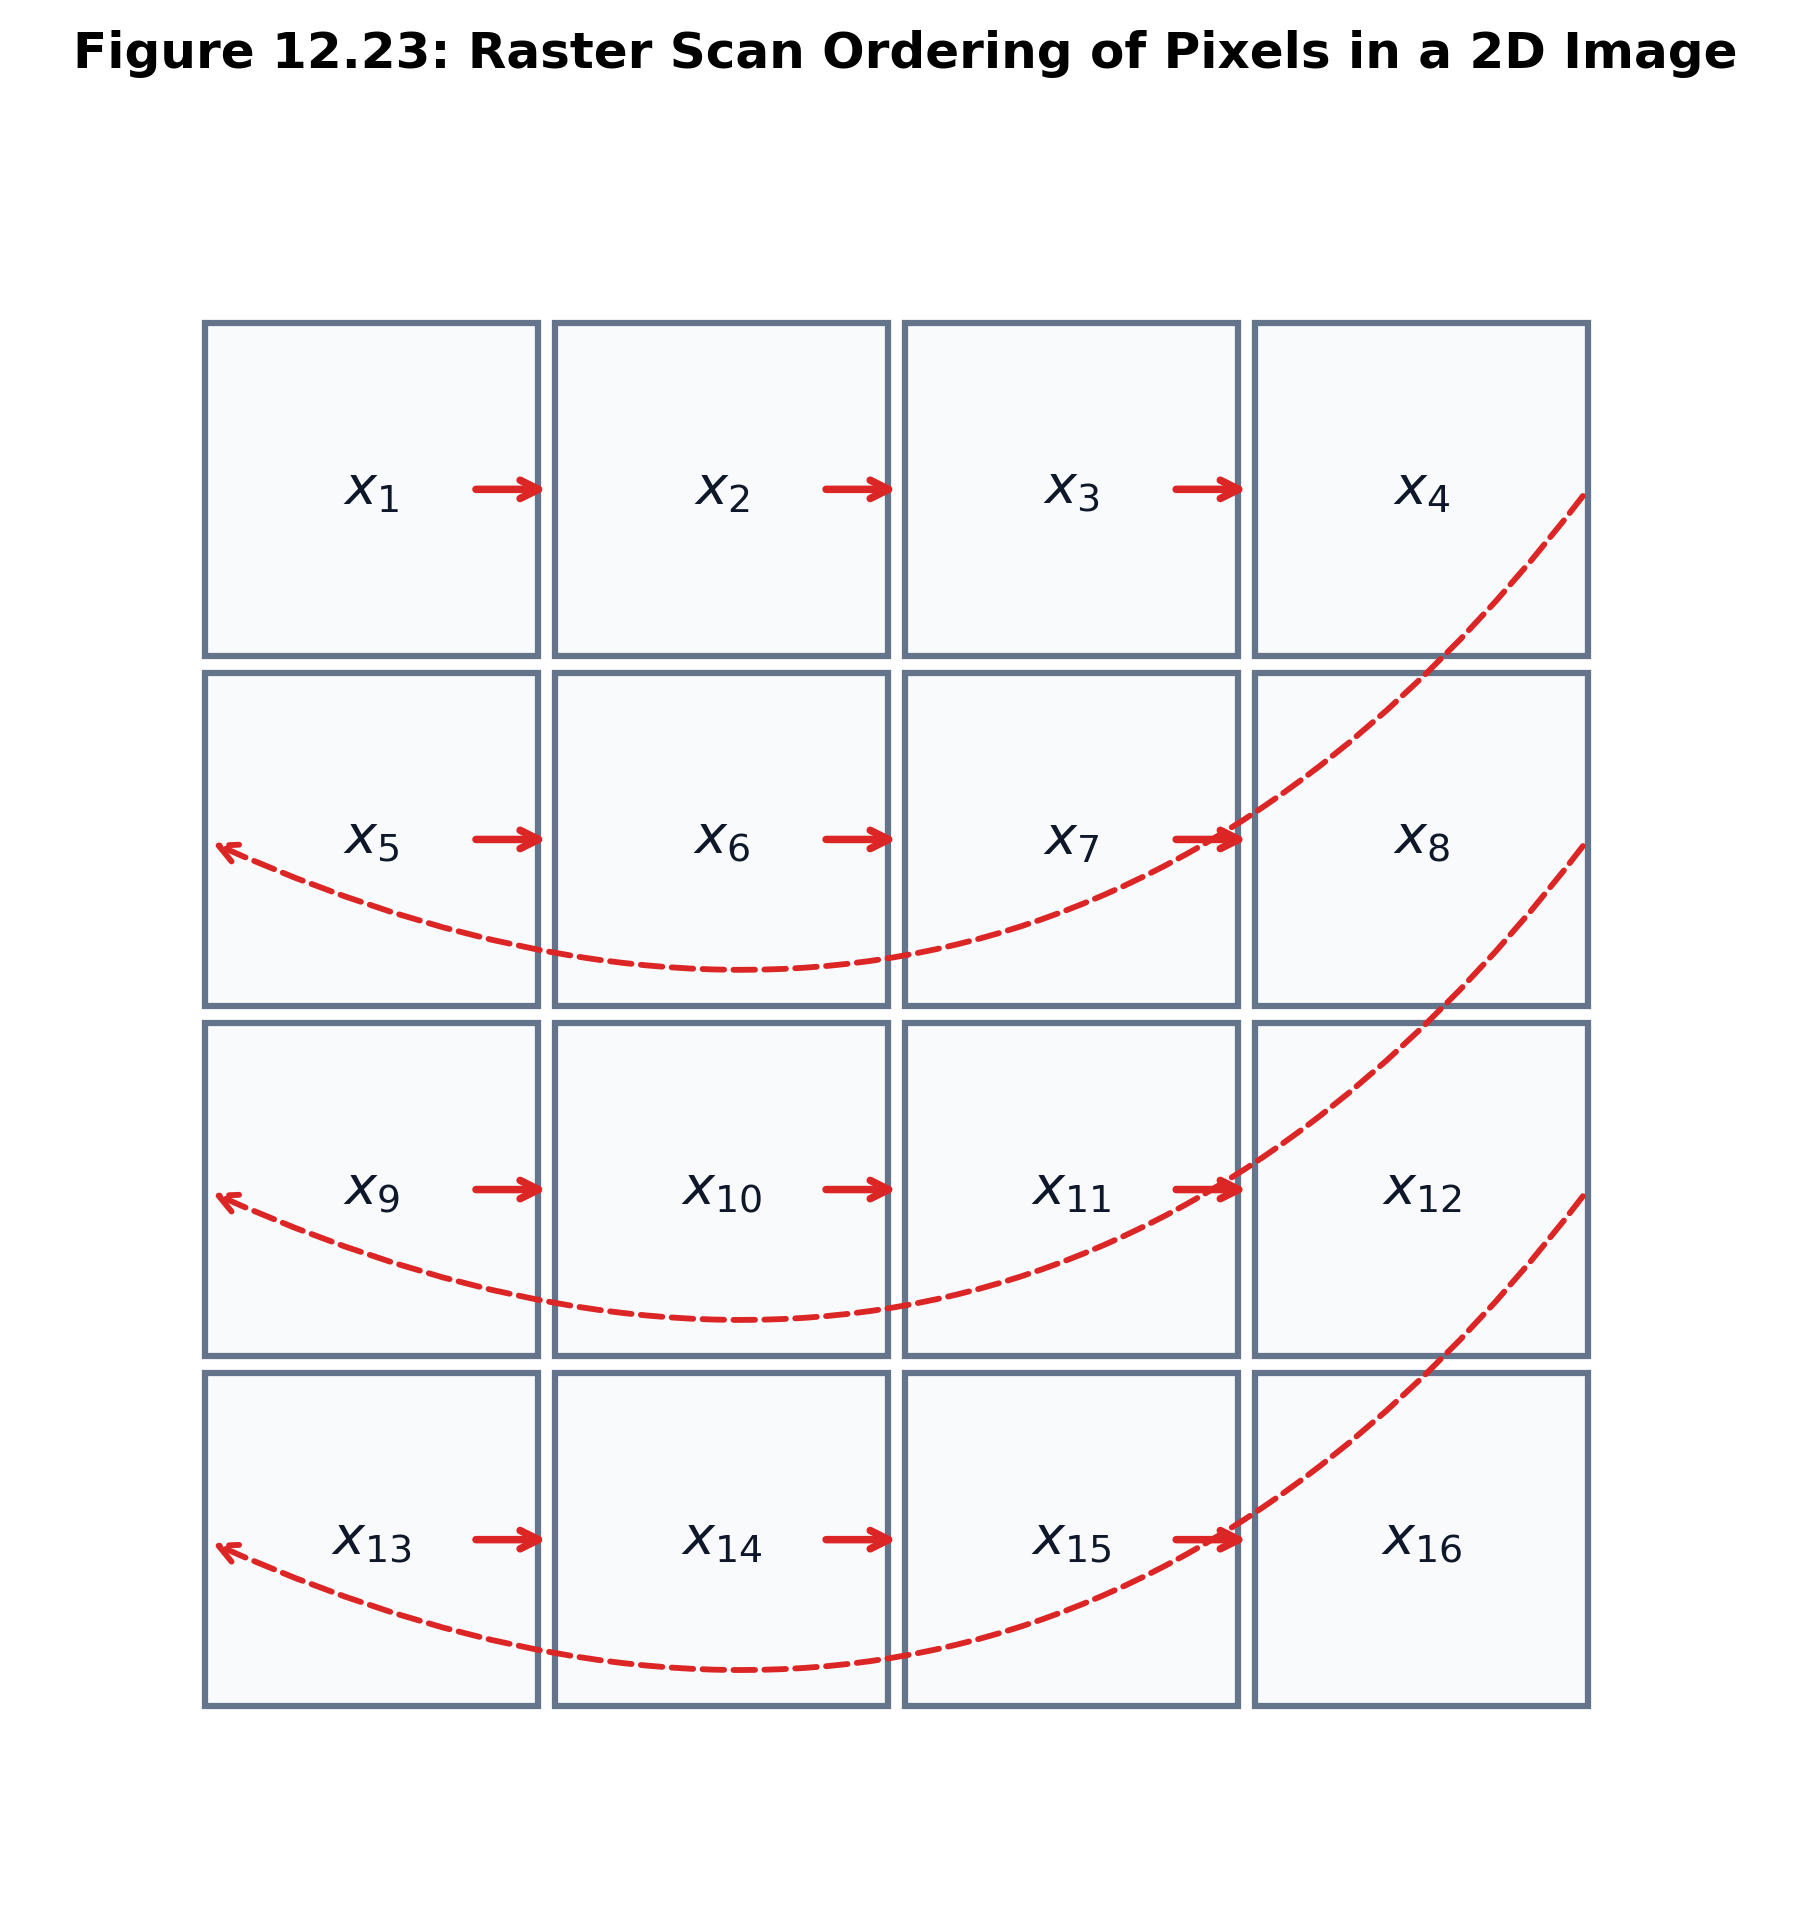

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/12/result/fig_12_24_autoregressive_image_sampling.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_12_24_autoregressive_image_sampling.png


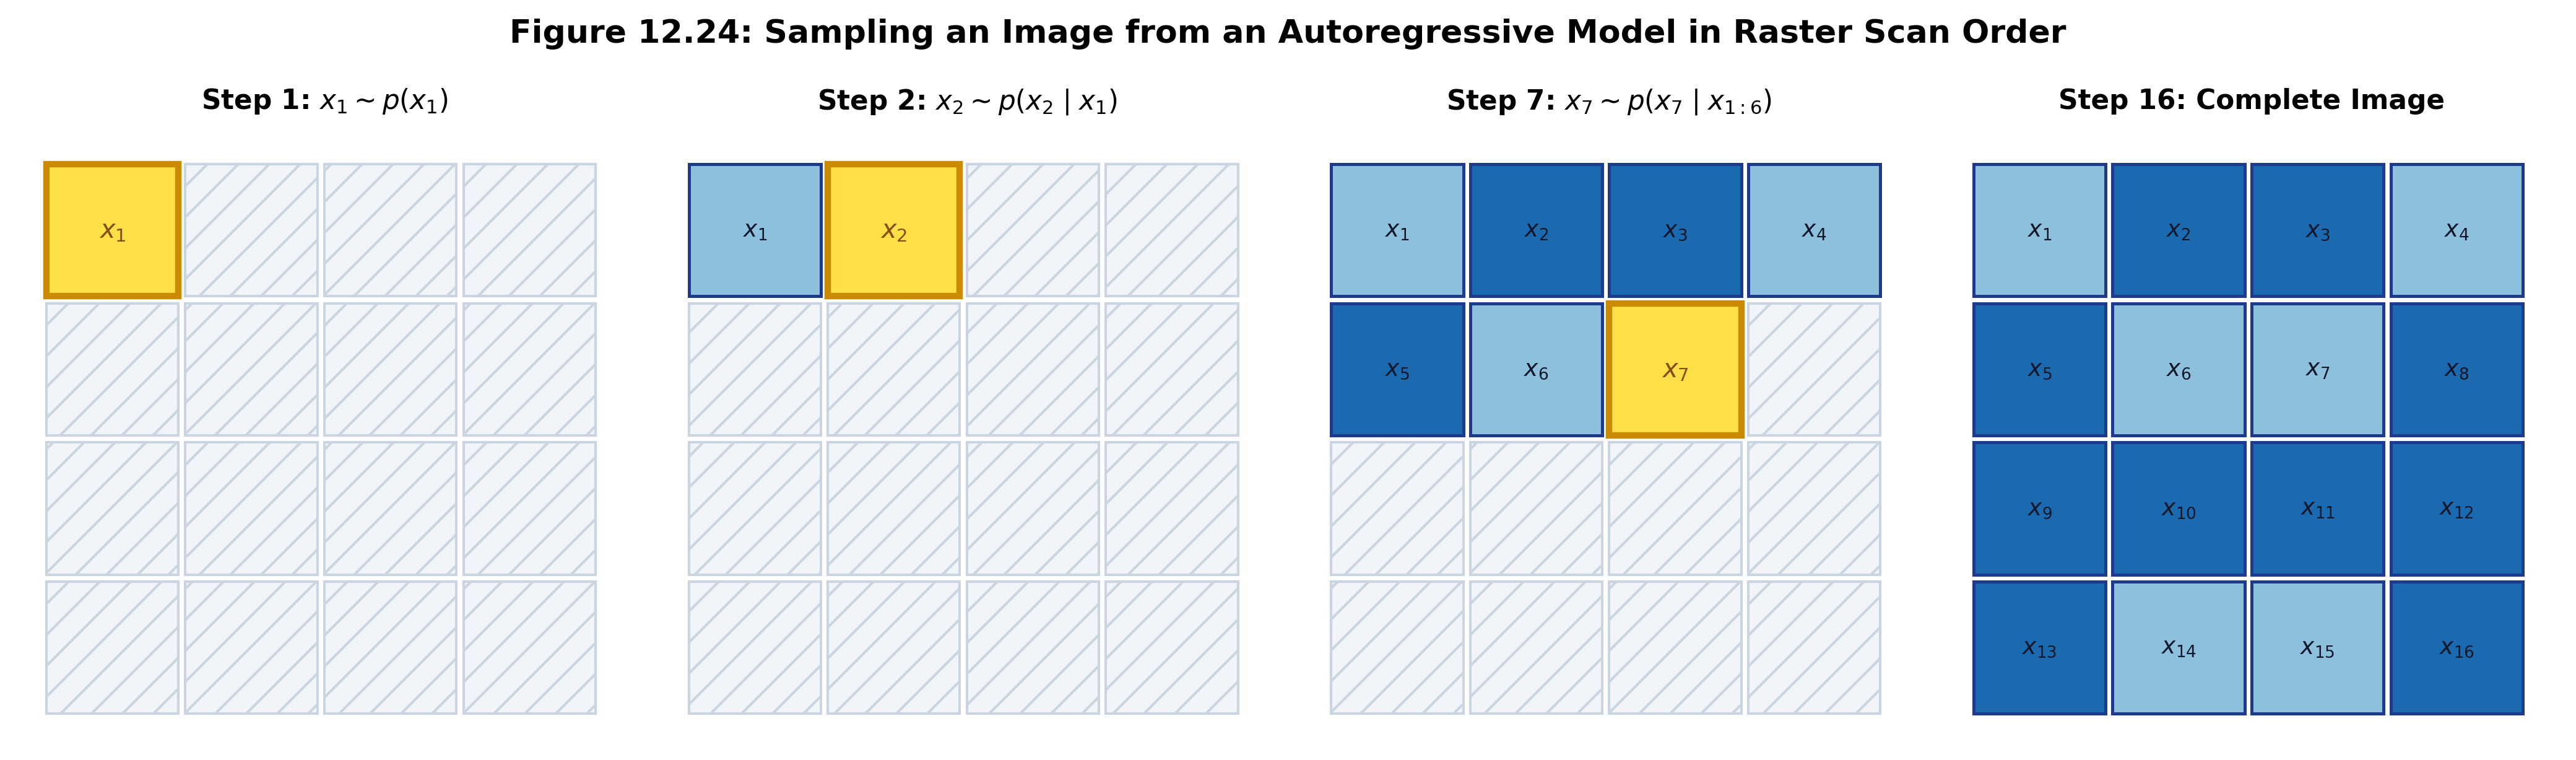

--- ベクトル量子化 (式 12.38) の検証 ---
入力点群:
[[ 0.85  0.15]
 [ 0.05  0.92]
 [-0.95 -0.05]
 [ 0.1  -1.1 ]]
最近傍コードブック割り当てインデックス: [0 1 2 3] (期待値: [0, 1, 2, 3])
量子化ベクトル z_q:
[[ 1.  0.]
 [ 0.  1.]
 [-1.  0.]
 [ 0. -1.]]
VQ損失: 0.009863, コミットメント損失: 0.009863, 総損失: 0.012328


In [3]:
# Figure 12.23 ラスタースキャン順序図の生成と表示
fig_12_23 = generate_figure_12_23()
plt.show()

# Figure 12.24 自己回帰サンプリング過程図の生成と表示
fig_12_24 = generate_figure_12_24()
plt.show()

# VectorQuantizer (式 12.38) の数値動作検証
vq = VectorQuantizer(num_embeddings=4, embedding_dim=2, commitment_cost=0.25, seed=42)
vq.codebook = np.array([
    [1.0, 0.0],
    [0.0, 1.0],
    [-1.0, 0.0],
    [0.0, -1.0],
])

query_points = np.array([
    [0.85, 0.15],
    [0.05, 0.92],
    [-0.95, -0.05],
    [0.10, -1.10],
])

indices, quantized_vectors = vq.quantize(query_points)
losses = vq.compute_loss(query_points, quantized_vectors)

print("--- ベクトル量子化 (式 12.38) の検証 ---")
print(f"入力点群:\n{query_points}")
print(f"最近傍コードブック割り当てインデックス: {indices} (期待値: [0, 1, 2, 3])")
print(f"量子化ベクトル z_q:\n{quantized_vectors}")
print(f"VQ損失: {losses['vq_loss']:.6f}, コミットメント損失: {losses['commitment_loss']:.6f}, 総損失: {losses['total_loss']:.6f}")


## 4. 音声データと音声トランスフォーマー (Audio Data & AST, Section 12.4.3)

音声波形 $s(t)$ は空気圧の振幅変化の1次元時系列ですが、トランスフォーマーで処理する際には2次元の **メル・スペクトログラム (Mel Spectrogram)** へと変換するのが極めて効果的です。

### 4.1 メル尺度 (Mel Scale) と短時間フーリエ変換 (STFT)
人間の聴覚系は周波数の対数的な変化に対して知覚的等間隔（音高）を感じます。この主観的評価に基づいて設計されたのが **メル尺度 (Mel Scale)** です：
$$m = 2595 \log_{10}\left(1 + \frac{f}{700}\right)$$
逆変換（メル値から周波数 Hz への復元）は次式で与えられます：
$$f = 700 \left(10^{m / 2595} - 1\right)$$

短時間フーリエ変換 (STFT) により得られた各時間フレームのパワースペクトル $|X(t, f)|^2$ に対し、メル尺度上に等間隔に配置された三角形状のフィルタバンクを乗算し、対数圧縮 $\log(\text{Mel} + \epsilon)$ を行うことでメル・スペクトログラムが得られます（Figure 12.25: ザトウクジラの歌の音響スペクトログラム）。

### 4.2 音声スペクトログラム・トランスフォーマー (Audio Spectrogram Transformer / AST)
メル・スペクトログラムは行が周波数帯、列が時間刻みの「2次元画像」と見なすことができます。
AST (Gong et al., 2021) では、メル・スペクトログラムを ViT と同様にパッチ（例えば $16 \times 16$）に分割して平坦化し、位置埋め込みと $\langle \text{class} \rangle$ トークンを加えてトランスフォーマー・エンコーダに入力することで、音声分類（AudioSet 等）において従来の CNN を凌駕する state-of-the-art 精度を達成しました。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/12/result/fig_12_25_mel_spectrogram.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_12_25_mel_spectrogram.png


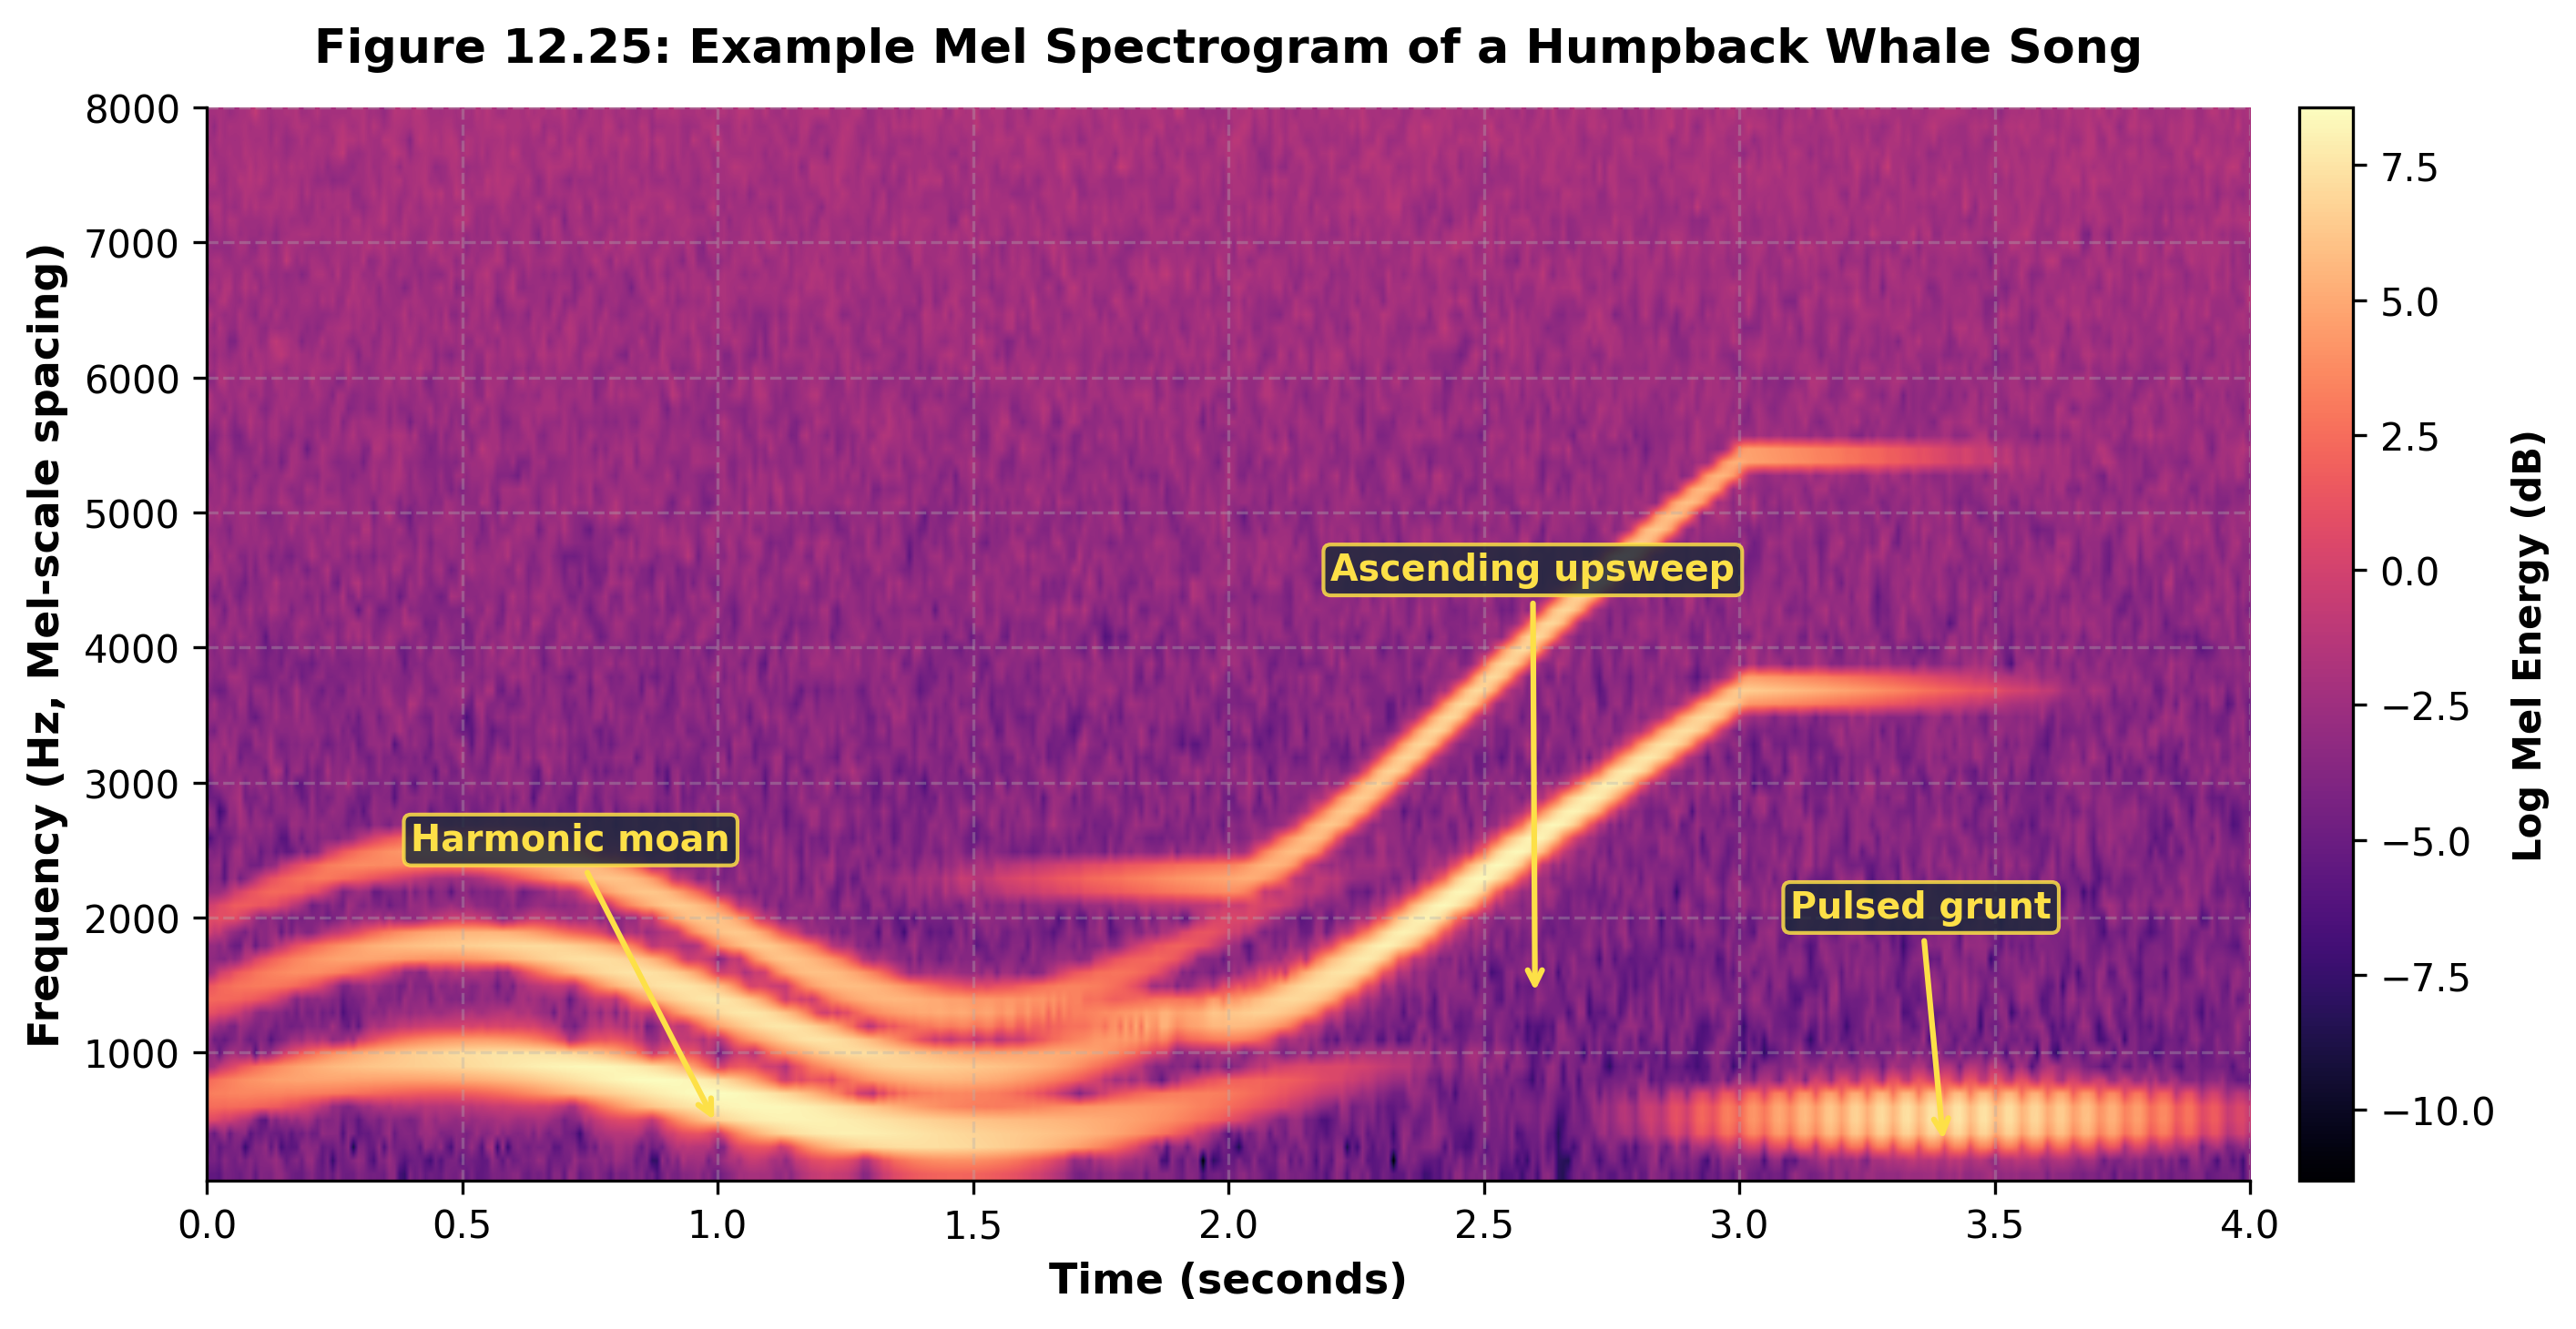

生成された合成音声サンプリング周波数: 16000 Hz, 長さ: 32000 サンプル
メル・スペクトログラム形状 (周波数ビン x 時間フレーム): (64, 197)
AST パッチ分割後のトークン数: 48, トークン次元: 256


In [4]:
# Figure 12.25 ザトウクジラの歌のメル・スペクトログラム生成と表示
fig_12_25 = generate_figure_12_25()
plt.show()

# AudioMelSpectrogramProcessor の動作検証
audio_proc = AudioMelSpectrogramProcessor(sample_rate=16000, n_fft=512, hop_length=160, n_mels=64)
t, whale_audio = audio_proc.synthesize_whale_song(duration_sec=2.0)
spec = audio_proc.compute_spectrogram(whale_audio)
patches = audio_proc.patchify_spectrogram(spec, patch_size=(16, 16))

print(f"生成された合成音声サンプリング周波数: {audio_proc.sample_rate} Hz, 長さ: {len(whale_audio)} サンプル")
print(f"メル・スペクトログラム形状 (周波数ビン x 時間フレーム): {spec.shape}")
print(f"AST パッチ分割後のトークン数: {patches.shape[0]}, トークン次元: {patches.shape[1]}")


## 5. テキスト音声合成 (Text-to-Speech / Vall-E, Section 12.4.4)

文章から対応する音声を生成するテキスト音声合成（TTS）において、従来の教師あり回帰モデルには以下の重大な限界がありました：
1. **多峰性の平均化**: 同一の文章であっても、抑揚・イントネーション・話速には多様な自然な解が存在します。二乗誤差回帰ではこれらが平均化され、不自然で平坦な音声になります。
2. **話者適応の困難**: 新しい話者の声を模倣するには大量の音声録音データが必要でした。

### 5.1 言語モデリングとしての音声生成 (Vall-E, Figure 12.26)
ニューラル音響コーデック（EnCodec 等）によるベクトル量子化技術を用いることで、連続音声波形は離散的な音響コードブック・トークン列へと変換できます。これにより、音声合成は純粋な **条件付き言語モデリングタスク** へと再定式化されます。

- **入力プロンプト**:
  1. 合成対象の文章を表す **テキスト・トークン**
  2. 模倣対象の話者のわずか3秒程度の音声から抽出された **音響プロンプト・トークン (Acoustic Prompt Tokens)**
- **自己回帰トランスフォーマー**: テキストプロンプトと音響プロンプトの連結系列を条件として、目的の音声トークンを順次サンプリングします。
- **音声デコーダ**: サンプリングされた離散トークンを連続波形へと逆変換し、高品質な自然音声を生成します。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/12/result/fig_12_26_valle_architecture.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_12_26_valle_architecture.png


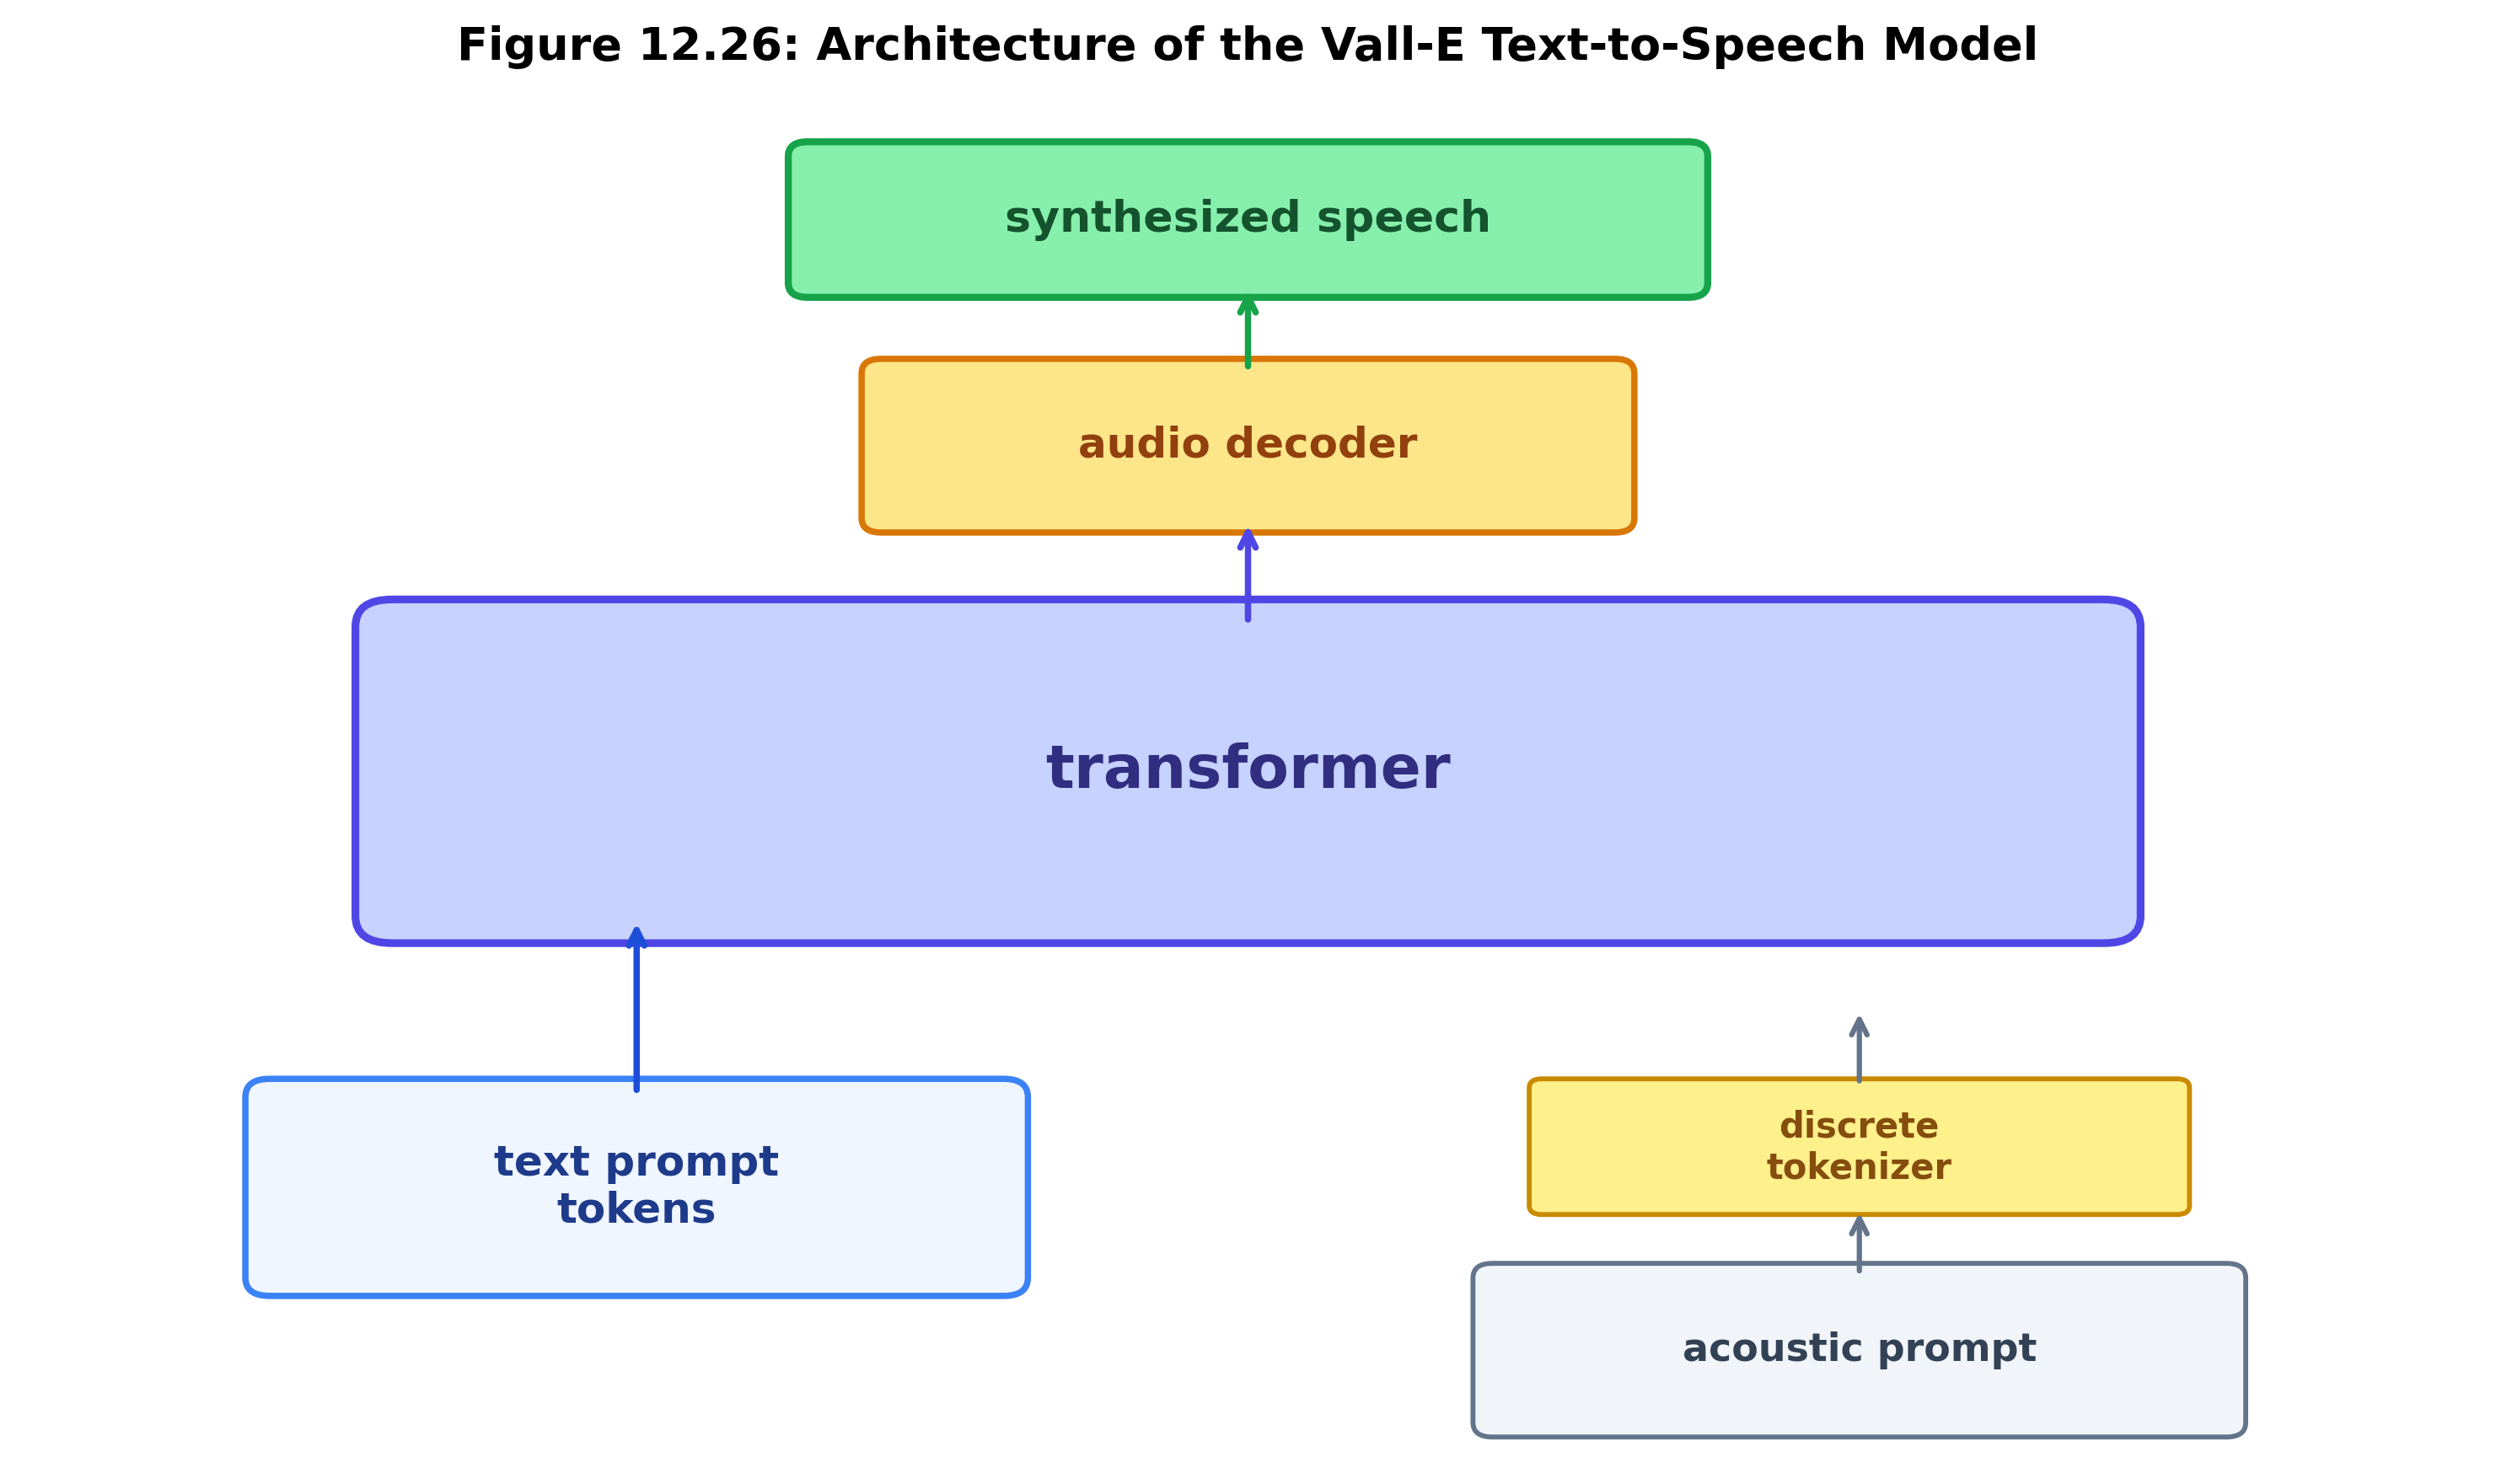

In [5]:
# Figure 12.26 Vall-E アーキテクチャ図の生成と表示
fig_12_26 = generate_figure_12_26()
plt.show()


## 6. 視覚と言語の統合トランスフォーマー (Vision & Language Transformers, Section 12.4.5)

テキスト・画像・音声がすべて離散トークンとして表現できるならば、トランスフォーマーの入出力空間においてモダリティの壁は完全に消滅します。

### 6.1 統一語彙体系と自己回帰モデリング (CM3 / CM3Leon, Figure 12.27)
テキスト語彙 $\mathcal{V}_{\text{text}}$ と画像コードブック $\mathcal{V}_{\text{image}}$ を連結し、特殊制御トークン（$[\text{BOS}], [\text{EOS}], [\text{BOI}], [\text{EOI}]$）を加えた巨大な単一語彙体系：
$$\mathcal{V}_{\text{total}} = \mathcal{V}_{\text{text}} \cup \mathcal{V}_{\text{image}} \cup \mathcal{V}_{\text{special}}$$
を構築します。

この統一表現により、CM3 (Aghajanyan et al., 2022) や CM3Leon (Yu et al., 2023) のようなモデルは、以下に示す多様なマルチモーダルタスクを単一の因果的自己回帰トランスフォーマーのみで完遂できます（Figure 12.27）：
1. **テキストからの画像生成 (Text-to-Image)**: テキストプロンプトを入力し、画像を自己回帰サンプリング。
2. **画像キャプション生成 (Image-to-Text)**: 画像トークンを入力し、説明文テキストをサンプリング。
3. **画像修復 (Inpainting / Completion)**: 欠損マスク領域をトークン補完。
4. **指示に基づく画像編集 (Instruction-Guided Editing)**: 元画像と編集指示テキストから修正画像を生成。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/12/result/fig_12_27_cm3leon_tasks.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_12_27_cm3leon_tasks.png


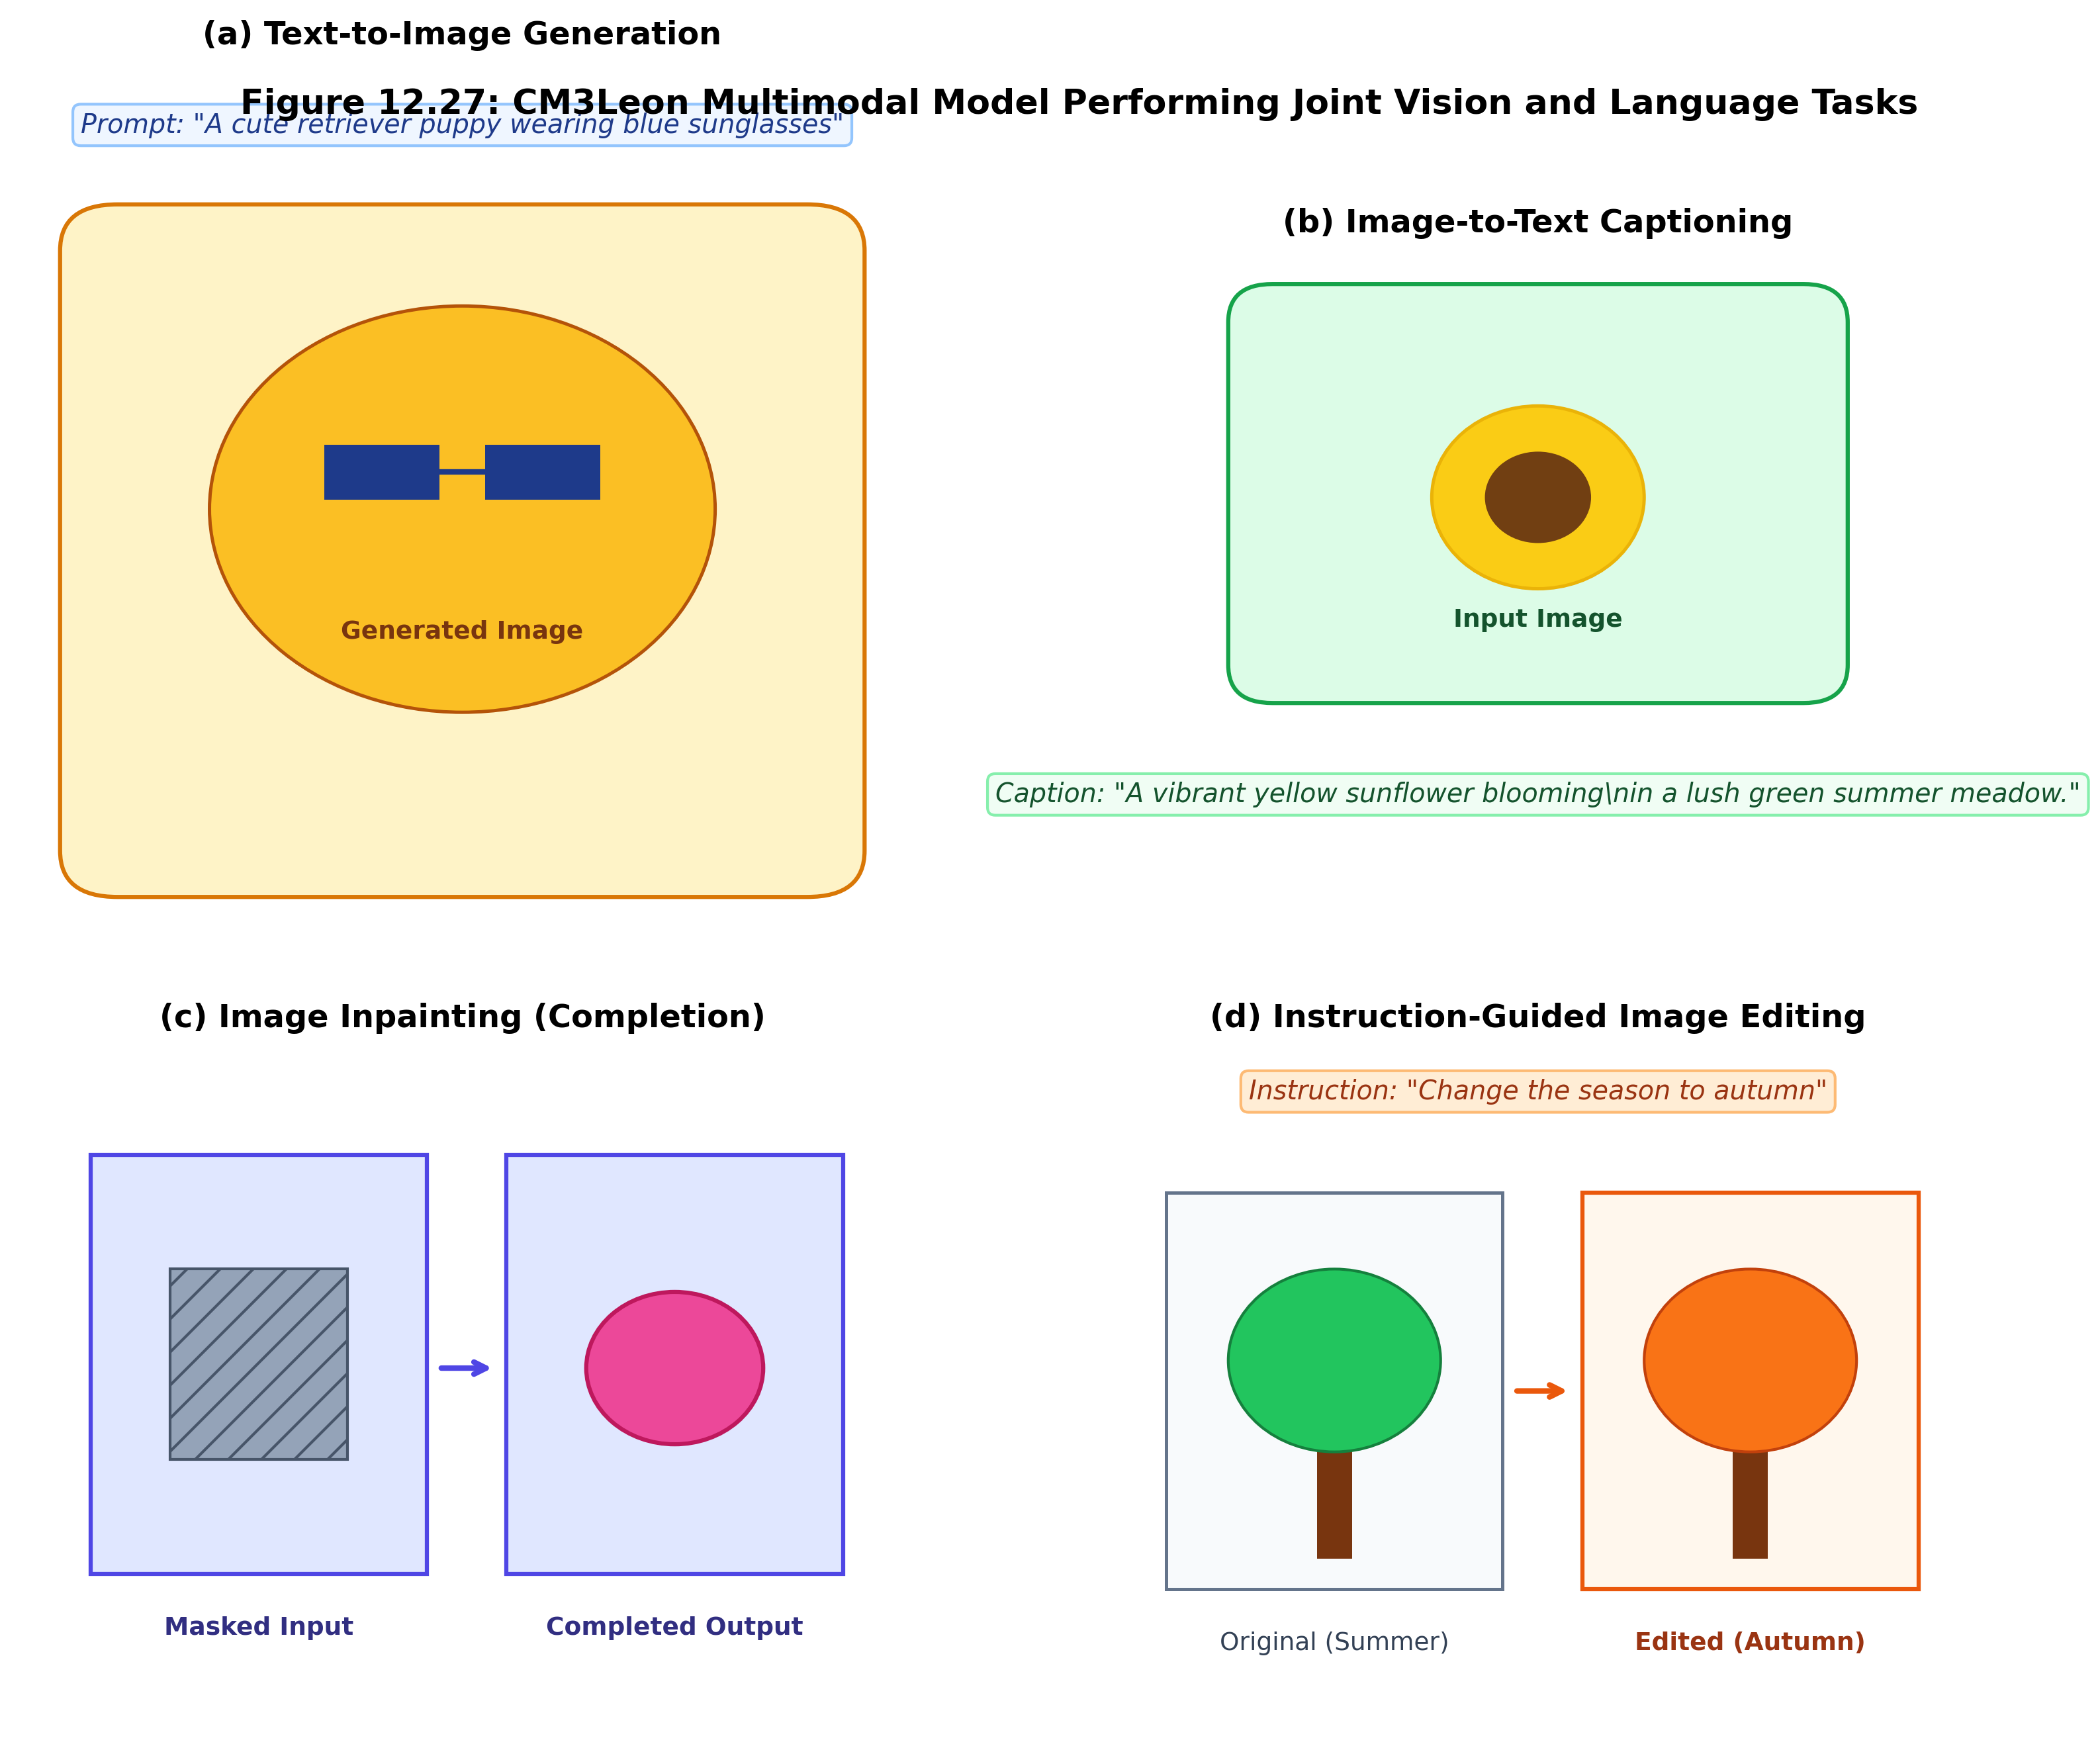

--- 統一マルチモーダル・トークン管理の検証 ---
総語彙数: 761 (特殊トークン: 5, テキスト: 500, 画像: 256)
Text-to-Image 系列: [0, 17, 50, 94, 2, 606, 607, 608, 3, 1]
Image-to-Text 系列: [0, 2, 705, 706, 3, 55, 65, 1]


In [6]:
# Figure 12.27 CM3Leon マルチモーダルタスク図の生成と表示
fig_12_27 = generate_figure_12_27()
plt.show()

# MultimodalTokenManager の動作検証
mgr = MultimodalTokenManager(text_vocab_size=500, image_codebook_size=256)
t2i_seq = mgr.format_sequence(text_ids=[12, 45, 89], image_ids=[101, 102, 103], task="text_to_image")
i2t_seq = mgr.format_sequence(text_ids=[50, 60], image_ids=[200, 201], task="image_to_text")

print("--- 統一マルチモーダル・トークン管理の検証 ---")
print(f"総語彙数: {mgr.total_vocab_size} (特殊トークン: {mgr.num_special}, テキスト: {mgr.text_vocab_size}, 画像: {mgr.image_codebook_size})")
print(f"Text-to-Image 系列: {t2i_seq}")
print(f"Image-to-Text 系列: {i2t_seq}")


## 7. まとめと章末演習問題 (Exercises 12.1 〜 12.16) への展開

### 本節の要点
1. **汎用モデルとしてのトランスフォーマー**: 空間局所性や並進等変性を仮定しないアーキテクチャの柔軟性により、言語のみならず画像 (ViT)、音声 (AST)、生成モデルへと普遍的に展開可能。
2. **パッチ分割と離散表現の重要性**: 画像の高解像度化にはパッチ分割、画像・音声の生成には多峰性を表現可能なベクトル量子化 (VQ, 式 12.38) とストレート・スルー勾配法 (STE) が不可欠。
3. **統一マルチモーダル基底モデル**: テキストトークンと画像コードブックの統一語彙体系により、単一の自己回帰トランスフォーマーで視覚・言語の双方向生成・編集タスクを包括的に統合 (CM3Leon)。

---

### 次なるステップ: 第12章 章末演習問題 (Exercises 12.1 〜 12.16)
次節では、第12章で学んだトランスフォーマーの全理論（注意係数の制約条件、クエリ・キー・バリューの内積幾何学、直交射影、位置埋め込み、自己回帰確率など）を網羅する **演習問題 12.1 から 12.16** の全16問の厳密な数学的証明と数値シミュレーション検証を行います。
